In [ ]:
!pip install deepface
import os
import pickle
import numpy as np
import cv2
from google.colab import drive
from deepface import DeepFace
from tqdm import tqdm
from scipy.spatial.distance import cosine

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- CONFIGURAZIONE ---
PATH_GALLERY = '/content/drive/MyDrive/BBA_Dataset/galleries'
PATH_DB_OUTPUT = '/content/drive/MyDrive/ProgettoBBA/gruppo12_embeddings_gallery_consegna.pkl'
DETECTOR_BACKEND = 'retinaface'
MODEL_NAME = 'ArcFace'

## Esempio RetinaNet Detection Face

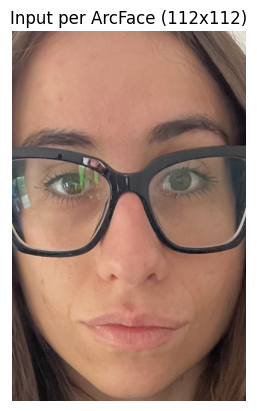

Shape del tensore di input: (1176, 742, 3)


In [16]:
# Scegli un'immagine di test dalla gallery
test_img_path = "/content/drive/MyDrive/BBA_Dataset/galleries/subject_16/natural_light/subj_16_natural_light_01.jpg"

# Estrai il volto preprocessato (esattamente come lo vede ArcFace)
# target_size=(112, 112) è lo standard per ArcFace
face_objs = DeepFace.extract_faces(
    img_path = test_img_path,
    detector_backend = 'retinaface',
    align = True
)

# Visualizziamo il risultato
import matplotlib.pyplot as plt

face_array = face_objs[0]['face'] # Questo è l'array normalizzato (valori 0-1)
plt.imshow(face_array)
plt.title(f"Input per ArcFace (112x112)")
plt.axis('off')
plt.show()

print(f"Shape del tensore di input: {face_array.shape}")
# L'output sarà (112, 112, 3) -> Altezza, Larghezza, Canali Colore

## Estrazione Feature

In [17]:
def crea_gallery_strutturata(root_folder):
    """
    Gestisce la struttura: Subject -> Condition -> Images
    Restituisce un dizionario: { 'subject_00': [Array1, Array2...], 'subject_01': ... }
    """
    database = {}

    if not os.path.exists(root_folder):
        print("Errore: Percorso non trovato.")
        return {}

    # Elenco delle cartelle dei soggetti (es. subject_00, subject_01...)
    subjects = [s for s in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, s))]
    subjects.sort() # Ordiniamo per pulizia (00, 01, 02...)

    print(f"Trovati {len(subjects)} soggetti. Inizio elaborazione...")

    for subject_id in tqdm(subjects):
        subject_path = os.path.join(root_folder, subject_id)

        # Inizializziamo la lista per questo studente
        # Un soggetto può avere più vettori (uno per ogni condizione di luce valida)
        database[subject_id] = []

        # os.walk ci permette di entrare in "low_light", "top_light" ecc. automaticamente
        for root, dirs, files in os.walk(subject_path):

            dirs.sort()

            files = sorted(files)

            for file_name in files:
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(root, file_name)

                    try:
                        # --- FASE 1 & 2: FACE DETECTION + EMBEDDING ---
                        # DeepFace.represent fa internamente:
                        # 1. Rileva il volto (Detection) usando 'detector_backend'
                        # 2. Allinea il volto (Alignment)
                        # 3. Estrae il vettore (Feature Extraction)

                        embedding_objs = DeepFace.represent(
                            img_path = img_path,
                            model_name = MODEL_NAME,
                            detector_backend = DETECTOR_BACKEND,
                            enforce_detection = True, # Se True, salta l'immagine se non trova facce
                            align = True
                        )

                        # Prendiamo l'embedding
                        embedding_list = embedding_objs[0]["embedding"]

                        # --- FASE 3: CONVERSIONE NUMPY ---
                        embedding_numpy = np.array(embedding_list, dtype=np.float32)

                        # Aggiungiamo alla lista di questo soggetto
                        database[subject_id].append(embedding_numpy)

                    except ValueError:
                        # Questo capita se il detector non trova un volto (es. foto troppo buia)
                        # Non stampiamo tutto per non intasare il log, magari solo un contatore
                        pass
                    except Exception as e:
                        print(f"Errore su {file_name}: {e}")

        # Info di debug per ogni soggetto
        n_embeddings = len(database[subject_id])
        if n_embeddings == 0:
            print(f"Attenzione: Nessun volto valido trovato per {subject_id}")
            del database[subject_id] # Rimuoviamo chiavi vuote

    return database

# --- ESECUZIONE ---
gallery_db = crea_gallery_strutturata(PATH_GALLERY)

# --- VERIFICA STRUTTURA ---
print("\n--- RISULTATO  ---")
for subject, embeddings in list(gallery_db.items())[:]: # Stampa i primi 3
    print(f"Soggetto: {subject} -> {len(embeddings)} vettori salvati (Shape: {embeddings[0].shape})")

# SALVATAGGIO
with open(PATH_DB_OUTPUT, 'wb') as f:
    pickle.dump(gallery_db, f)
print(f"Database salvato in {PATH_DB_OUTPUT}")

Trovati 20 soggetti. Inizio elaborazione...


100%|██████████| 20/20 [01:35<00:00,  4.77s/it]


--- RISULTATO  ---
Soggetto: subject_00 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_01 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_02 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_03 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_04 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_05 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_06 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_07 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_08 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_09 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_10 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_11 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_12 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_13 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_14 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_15 -> 8 vettori salvati (Shape: (512,))
Soggetto: subject_16 -> 8 vettori salvati (Shape: (5

In [6]:
if os.path.exists(PATH_DB_OUTPUT):
    with open(PATH_DB_OUTPUT, 'rb') as f:
        gallery_db = pickle.load(f)
    print(f"Database caricato con successo! Trovati {len(gallery_db)} soggetti.")

Database caricato con successo! Trovati 20 soggetti.


In [18]:
# --- 1. CONFIGURAZIONE ---
# Percorso del database creato prima
PATH_DATABASE = '/content/drive/MyDrive/ProgettoBBA/embeddings_gallery.pkl'

# Percorso della foto singola che si vuole testare
FOTO_DA_TESTARE = '/content/drive/MyDrive/BBA_Dataset/probes/subject_16/low_light/subj_16_low_light_00.jpg'

# Modelli (Stessi usati per creare il DB)
MODEL = "ArcFace"
BACKEND = "retinaface"

# --- 2. LOGICA DI RICONOSCIMENTO ---
def identica_persona(path_foto, path_db):


    # A. Carichiamo il Database
    with open(path_db, 'rb') as f:
        gallery_db = pickle.load(f)

    # B. Calcoliamo l'embedding della foto nuova
    try:
        embedding_objs = DeepFace.represent(
            img_path=path_foto,
            model_name=MODEL,
            detector_backend=BACKEND,
            enforce_detection=True
        )
        target_embedding = embedding_objs[0]["embedding"]
    except ValueError:
        print("Nessun volto trovato nella foto!")
        return

    # C. Confronto con TUTTI i soggetti del DB (Best Match)
    best_match_name = "Sconosciuto"
    best_match_score = 100.0 # Partiamo da un numero alto

    print(f"Confronto con {len(gallery_db)} soggetti nel database...")

    for subject_name, vectors in gallery_db.items():
        # Confronta con ogni foto salvata di questo soggetto
        for db_vector in vectors:
            distanza = cosine(target_embedding, db_vector)

            # Se troviamo una distanza migliore (più bassa), aggiorniamo il vincitore
            if distanza < best_match_score:
                best_match_score = distanza
                best_match_name = subject_name

    # --- 3. RISULTATO ---
    print("\n" + "="*30)
    print(f"IDENTITÀ RILEVATA: {best_match_name}")
    print(f"Distanza (Errore): {best_match_score:.4f}")

    # Interpretazione veloce del risultato per ArcFace
    if best_match_score < 0.4:
        print("✅ Affidabilità: ALTA (Sicuramente lui/lei)")
    elif best_match_score < 0.55:
        print("⚠️ Affidabilità: MEDIA (Probabilmente lui/lei)")
    else:
        print("❌ Affidabilità: BASSA (Potrebbe essere un errore o uno sconosciuto)")
    print("="*30)

# --- ESECUZIONE ---
identica_persona(FOTO_DA_TESTARE, PATH_DATABASE)

Confronto con 20 soggetti nel database...

IDENTITÀ RILEVATA: subject_16
Distanza (Errore): 0.2633
✅ Affidabilità: ALTA (Sicuramente lui/lei)


# Analisi

Analisi su 160 vettori. Cerco Genuini con distanza > 0.5...

--- REPORT GENUINI PROBLEMATICI (Distanza > 0.5) ---
Trovate 56 coppie critiche.
1. Soggetto: subject_05 | Distanza: 0.8466 | Confronto img[3] vs img[4]
2. Soggetto: subject_05 | Distanza: 0.8332 | Confronto img[2] vs img[4]
3. Soggetto: subject_05 | Distanza: 0.8305 | Confronto img[3] vs img[6]
4. Soggetto: subject_05 | Distanza: 0.8208 | Confronto img[3] vs img[5]
5. Soggetto: subject_02 | Distanza: 0.8154 | Confronto img[2] vs img[6]
6. Soggetto: subject_05 | Distanza: 0.8128 | Confronto img[3] vs img[7]
7. Soggetto: subject_05 | Distanza: 0.8070 | Confronto img[1] vs img[2]
8. Soggetto: subject_05 | Distanza: 0.8008 | Confronto img[0] vs img[3]
9. Soggetto: subject_05 | Distanza: 0.7979 | Confronto img[1] vs img[3]
10. Soggetto: subject_05 | Distanza: 0.7917 | Confronto img[0] vs img[2]


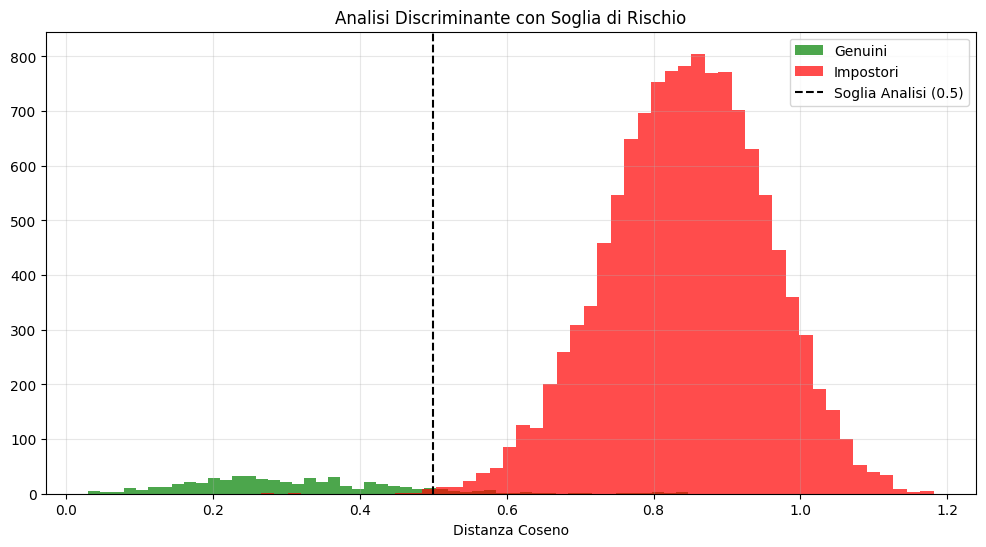

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cosine

def analizza_e_trova_errori(database, soglia_allarme=0.5):
    """
    Oltre a fare i grafici, restituisce la lista dei 'Genuini Lontani'.
    soglia_allarme: Valore sopra il quale un confronto genuino è considerato 'a rischio'.
                    Guardando il grafico, 0.5 è un buon punto di partenza.
    """
    genuine_scores = []
    impostor_scores = []

    # Lista per salvare i dettagli dei casi problematici
    # Format: (distanza, id_soggetto, indice_vettore_1, indice_vettore_2)
    worst_genuines = []

    # Appiattiamo il DB mantenendo i riferimenti
    all_vectors = []

    for subject_id, vector_list in database.items():
        for idx, vector in enumerate(vector_list):
            # Salviamo anche l'indice originale per capire "quale foto" del soggetto è
            all_vectors.append((subject_id, vector, idx))

    num_samples = len(all_vectors)
    print(f"Analisi su {num_samples} vettori. Cerco Genuini con distanza > {soglia_allarme}...")

    for i in range(num_samples):
        for j in range(i + 1, num_samples):

            id_1, vec_1, original_idx_1 = all_vectors[i]
            id_2, vec_2, original_idx_2 = all_vectors[j]

            dist = cosine(vec_1, vec_2)

            if id_1 == id_2:
                # Genuini
                genuine_scores.append(dist)

                # SE la distanza è alta (vicina agli impostori), salviamo il caso
                if dist > soglia_allarme:
                    worst_genuines.append({
                        'soggetto': id_1,
                        'distanza': dist,
                        'img_idx_A': original_idx_1, # Indice della foto nella lista del soggetto
                        'img_idx_B': original_idx_2
                    })
            else:
                # Impostori
                impostor_scores.append(dist)

    # --- ORDINAMENTO E REPORT ---
    # Ordiniamo i peggiori genuini dal più distante al meno distante
    worst_genuines.sort(key=lambda x: x['distanza'], reverse=True)

    print(f"\n--- REPORT GENUINI PROBLEMATICI (Distanza > {soglia_allarme}) ---")
    if not worst_genuines:
        print("Ottimo! Nessun genuino ha superato la soglia di allarme.")
    else:
        print(f"Trovate {len(worst_genuines)} coppie critiche.")
        # Stampiamo i primi 10 peggiori
        for k, caso in enumerate(worst_genuines[:10]):
            print(f"{k+1}. Soggetto: {caso['soggetto']} | Distanza: {caso['distanza']:.4f} "
                  f"| Confronto img[{caso['img_idx_A']}] vs img[{caso['img_idx_B']}]")

    # --- VISUALIZZAZIONE ---
    plt.figure(figsize=(12, 6))
    plt.hist(genuine_scores, bins=50, alpha=0.7, color='green', label='Genuini')
    plt.hist(impostor_scores, bins=50, alpha=0.7, color='red', label='Impostori')

    # Aggiungiamo una linea verticale per la soglia
    plt.axvline(x=soglia_allarme, color='black', linestyle='--', label=f'Soglia Analisi ({soglia_allarme})')

    plt.title("Analisi Discriminante con Soglia di Rischio")
    plt.xlabel("Distanza Coseno")
    plt.legend()
    plt.grid(True, alpha=0.3)

    return genuine_scores, impostor_scores, worst_genuines

# --- ESECUZIONE ---
# Assumiamo che 'gallery_db' sia già caricato
if 'gallery_db' in locals():
    # Imposto soglia a 0.5 basandomi grafico (dove il verde inizia a calare e il rosso sale)
    _, _, cattivi_esempi = analizza_e_trova_errori(gallery_db, soglia_allarme=0.5)
    plt.show()